# August 2026 canonical forecast — s01 desktop retune, LOL 200K, headwind −1,245,000 (2026-07-28)

> **Desktop model LOCKED to the s01 configuration (2026-07-29).** Build history this cycle, all at the
> 2026-07-28 anchor on the same data:
>
> | build | desktop params | LOL ceiling | headwind | ramp start | desktop Dec-15 | Aug trough |
> |---|---|--:|--:|---|--:|--:|
> | baseline | July's lock | 125,000 | −1,345,000 | 2026-04-01 | 48,520,714 | — |
> | — | July's lock | 165,000 | −1,345,000 | 2026-04-01 | 48,561,795 | — |
> | — | July's lock | 165,000 | −1,295,000 | 2026-04-01 | 48,611,795 | — |
> | — | July's lock | 180,000 | −1,245,000 | 2026-04-01 | 48,672,970 | 43,453,752 |
> | — | July's lock | 180,000 | −1,245,000 | 2026-07-28 | 48,672,970 | 43,833,674 |
> | — | s01 | 180,000 | −1,245,000 | 2026-07-28 | 48,678,612 | 45,193,561 |
> | **this build** | **s01** | **200,000** | **−1,245,000** | **2026-07-28** | **48,703,960** | **45,223,249** |
>
> Every row is a build that exists on disk; all are frozen and none is ever re-run. The last two differ
> in exactly one input (the `l` curve ceiling), which is what makes the +25,348 between them attributable.
>
> **The retune** lifts the summer trough **+1,359,887** for only **+5,642** at Dec-15 — 11% of the
> ±50,000 budget. Measured like-for-like with both sides on the 180K curve, in
> `../../research/param-scans/summer-trough-v2/s01_canonical_desktop.ipynb`, which is deliberately left
> on 180K builds: repointing it at 200K would confound the config evidence with the ceiling change.

**Not yet a delivered forecast.** Two of the three overlay curves are still stale carry-forwards from
July. See the caveats cell at the bottom before quoting anything.

Ported from `data-official/2026-07/july_canonical_v2026-06-29.ipynb`.

## What has changed since July

**1. The seam moved 2026-07-06 → 2026-07-28** (training through 2026-07-27, the freshest day both
platforms have complete). Both platforms share the seam, as in July.

**2. The launch-on-login (`l`) ceiling was raised 125,000 → 200,000 DAU/day** (task-owner decision;
165K and 180K variants were built and reviewed first, and both remain on disk). Curve shape:

| span | value |
|---|---|
| ≤ 2026-05-07 | 0 (pre-rollout) |
| 2026-05-08 → 2026-06-23 | **measured** — FF152-excluded, interpolated 7d trailing MA of the holdback excess; 130,296 at the last clean day |
| 2026-06-24 → 2026-07-18 | **extrapolated** — linear ramp at 2,714/day |
| 2026-07-19 → 2027-12-31 | flat at **200,000** |

At 200K the plateau is only 9 days wide inside training (180K: 16 days; 165K: 22), so the last weeks of
training see a still-rising subtraction rather than a flat one. All three ceilings are reached before the
2026-07-27 training end.

`l` is a *bidirectional* overlay — subtracted from `modern_windows` training rows before mozaic, added
back after — so its Dec-15 effect need not equal the raw curve delta, and it is **config-dependent**:
180K → 200K is worth +25,348 under s01 but only ~+7,211 under July's flatter config, because s01's 2.1×
changepoint flexibility responds far more to a modified training series. `[desktop-dec15]` attributes
both LOL steps.

**The ceiling is entirely an extrapolation judgement, and it is unfalsifiable.** Measured data stops at
130,296 on 2026-06-23, so 125K, 165K, 180K and 200K are *indistinguishable on the evidence* — the clean
window closed permanently on 2026-06-24 when the holdback control received the feature, so no future
telemetry can adjudicate them either. An independent convolution model of the same effect lands near
220,000/day, making 200K a ~20K/day haircut — the least conservative of the three built (180K ~40K,
165K ~55K).

**3. The Win10 headwind (`h`) desktop anchor was attenuated +100,000** to **−1,245,000**. Fourth
successive attenuation, none yet validated against telemetry — see the caveats cell. **Mobile unchanged
at −27,162.**

**4. The headwind ramp was RE-ANCHORED to start at the seam** (`start_date` 2026-04-01 → 2026-07-28), a
change of modeling convention. The ramp still terminates on the same Dec-15 anchor, so **the KPI is
unchanged**; what changes is the interior. Previously the ramp began 2026-04-01 but applied only from the
seam forward, switching on at 45.7% of full value — **−569,419 in one step**, which a 28-day trailing MA
cannot physically do, and which accounted for 100.9% of the visible seam discontinuity. Measurement:
`desktop_adjustment_ladder.ipynb`.

| date | old ramp | new ramp | lift |
|---|--:|--:|--:|
| 2026-07-28 (seam) | −569,419 | 0 | **+569,419** |
| 2026-10-01 | −883,081 | −578,036 | +305,046 |
| 2026-12-15 | −1,245,000 | −1,245,000 | **0** |

**Comparability caveat:** July's and June's delivered curves used the old convention and their specs are
untouched, so the prior line still reproduces July's delivered number exactly — but between the seam and
Dec-15 the two curves are on **different conventions** and are not comparable there. At Dec-15 they are.

**5. The desktop model was RETUNED to the s01 configuration** — new this cycle, and the only change that
required a model rebuild besides the LOL ceiling.

| param | July's lock | s01 |
|---|--:|--:|
| `seasonality_regime` | auto | **multiplicative** |
| `changepoint_prior_scale` | 0.08983 | **0.1849** |
| `changepoint_range` | 0.65 | **0.734** |
| `recent_weeks` | 13 | **17** |
| `n_changepoints` | 25 | **35** |
| `seasonality_prior_scale` | 0.00825 | 0.00825 (unchanged) |
| all four `holiday_*` | defaults | defaults (**unchanged**) |

s01 is the 28-point Latin-hypercube winner from July's own Aug-trough search
(`research/param-scans/aug22-retune/`), which never adopted it. Rebuilt on August data it satisfies all
three objectives simultaneously: trough inside the 45–46M target band, Dec-15 inside ±50,000, and a
markedly better seam handoff derivative (kink **−19,702/day vs −74,237**, i.e. 73% smaller).

> The kink figures were re-measured 2026-07-29 after the seam trend-estimator fix (`Fix A`, see the
> caveats cell). Pre-fix they read −20,604 vs −72,593; the *ranking* was never in doubt but the
> magnitudes were contaminated by the estimator defect, so quote the values above.

**Holiday parameters were permanently excluded from the search.** They produce strictly local effects, so
using them to move a whole-season quantity is compensating for an overall trend with a small regional
fix. `holiday_max_radius` measured as the *second-largest* trough lever and was declined on principle.
`scripts/run_trend_only_grid.py` refuses holiday overrides so this cannot be reintroduced by accident.

`h` remains a **display-layer** adjustment applied to the 28-day MA in `[compute-series]`, not baked into
the parquet.

## What is still held fixed from July

| Component | Value | Note |
|---|---|---|
| Mobile params | `cps=0.035, cpr=0.75, ncp=25, recent=13, threshold=−0.055` | July's `grad_moderate` grid result |
| MozillaOnline (`o`) | Brad's official CN migration curve | **STALE** — byte-identical carry-forward |
| Marketing lift (`m`) | June-anchored Fenix paid curve | **STALE** — byte-identical carry-forward |

Mobile is untouched by every change above — `l` is desktop-only and the desktop retune does not touch it,
so the mobile forecast is the same run as the 125K baseline. Any mobile movement versus July is the data
refresh alone; `[mobile-dec15]` asserts that drift is exactly zero.

## Reference points

`[desktop-dec15]` decomposes the gap between July's delivered number and this build into **five**
attributed steps: data refresh, LOL 125K→180K, headwind attenuation, the s01 retune, and LOL 180K→200K.

**Every step is measured against a build that differs from its comparator in exactly one input**, and
each is *pinned* as a constant rather than recomputed. Two consequences worth knowing:

- **The ledger is a real check, not a tautology.** Because the steps are pinned independently of this
  parquet, they do not close by construction — so `[desktop-dec15]` asserts the chain sums to the
  measured Dec-15, which fails loudly if a constant goes stale or the wrong parquet is loaded. A residual
  ledger cannot test itself.
- **No comparison build was ever re-run to produce these numbers.** Each step differences artifacts that
  already existed. **Historical builds are locked** — published deltas were quoted against them, and a
  chain whose links move cannot be audited. The intermediate parquets are also gitignored and GCS-bound,
  which is the second reason the steps are pinned rather than loaded.


In [1]:
# [setup]
import os
import subprocess
import glob
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from google.cloud import bigquery

# Anchor execution at git root so relative paths work regardless of notebook location.
os.chdir(subprocess.run(['git', 'rev-parse', '--show-toplevel'],
                        capture_output=True, text=True).stdout.strip())

# --- File paths ---
# AUGUST cycle, s01 desktop lock. One forecast per platform, both anchored to forecast_start
# 2026-07-28 (trained through 2026-07-27, the freshest day both legacy_desktop and glean_mobile have
# complete). Iran is included like any other country -- queried natively, with the 2026-03-01 ->
# 05-25 shutdown gap covered by mozaic's built-in counterfactual fill. Not a separate series.
#
# MOBILE carries July's locked parameters unchanged. DESKTOP is retuned to the s01 config
# (regime=multiplicative, cps 0.1849, cpr 0.734, recent 17, ncp 35) -- see change 5 in the intro.
# Holiday knobs stay at package defaults on both platforms and are excluded from tuning by policy.
# Overlay state differs per code:
#   l (launch-on-login) -- REBUILT 2026-07-29, ceiling raised 125,000 -> 180,000 DAU/day (a 165,000
#                          variant is also on disk). Desktop only. Baked into the parquet, so a ceiling
#                          change requires a model rebuild -- unlike h.
#   o (MozillaOnline)   -- byte-identical carry-forward from July. STALE.
#   m (marketing lift)  -- byte-identical carry-forward from July. STALE. Mobile only.
#   h (Win10 headwind)  -- desktop anchor ATTENUATED +100,000 to -1,245,000 (July: -1,345,000), an
#                          ALTERNATE value under evaluation; mobile unchanged at -27,162. ALSO
#                          RE-ANCHORED: the ramp now starts at the seam, not 2026-04-01. Display layer,
#                          so neither change needs a model re-run.
# The desktop parquet below therefore differs from the baseline in BOTH the LOL ceiling and the model
# config; the mobile parquet is the SAME run (l is desktop-only, and the retune is desktop-only). See
# the intro cell.
DESKTOP_FORECAST_PATH = (
    "data-official/2026-08/desktop_locked/"
    "mozaic_daily_forecast.2026-07-28.ld-D.adj-lo.parquet"
)
MOBILE_FORECAST_PATH = (
    "data-official/2026-08/mobile_baseline_2026-07-28/"
    "cps0.035_thresh055_recent13_cpr0.75_ncp25_clip0.6_sps0.1/"
    "mozaic_daily_forecast.2026-07-28.gm-D.adj-m.parquet"
)

# Prior (N-1) = JULY's DELIVERED forecast. Unlike June->July, no reconstruction hack is needed here:
# July's MozillaOnline tailwind is the measured `o` overlay baked into the parquet, not a flat +500K
# step bolted on at the display layer. So the prior line is just (parquet + July's own headwind).
PREV_FORECAST_DESKTOP_PATH = (
    "data-official/2026-07/desktop_locked/"
    "mozaic_daily_forecast.2026-07-06.ld-D.adj-lo.parquet"
)
PREV_FORECAST_MOBILE_PATH = (
    "data-official/2026-07/mobile_refresh_2026-07-06/"
    "cps0.035_thresh055_recent13_cpr0.75_ncp25_clip0.6/"
    "mozaic_daily_forecast.2026-07-06.gm-D.adj-m.parquet"
)

# Display-layer adjustments (the Win10 headwind `h`): linear ramp reaching desktop -1,245,000 /
# mobile -27,162 at the 2026-12-15 anchor, ramping from the SEAM (start_date 2026-07-28).
#
# The seam start is new this cycle. Under the old convention the ramp began 2026-04-01 but was applied
# only from the seam forward, so it switched on at 45.7% of full value (-569,419) as a one-day level
# step -- which was 100.9% of the seam discontinuity in the published chart. Ramping from the seam hits
# the identical Dec-15 anchor while starting at zero, so the KPI is untouched and the interior lifts.
#
# The prior line reads July's OWN spec dir, which still holds -1,345,000 AND the old 2026-04-01 ramp
# start. Keeping the two separate is what makes both changes safe: editing August's spec cannot
# retroactively alter the July comparison curve, and [desktop-dec15] asserts July still reproduces its
# delivered value. The trade-off is that the two curves are on different conventions between the seam
# and Dec-15, so only the Dec-15 comparison is apples-to-apples.
ADJUSTMENTS_DIR = "data-official/2026-08/adjustments"
PREV_ADJUSTMENTS_DIR = "data-official/2026-07/adjustments"

PLOTS_DIR = "data-official/2026-08/plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# --- Date constants ---
DISPLAY_START = pd.Timestamp("2026-01-01")
DISPLAY_END = pd.Timestamp("2026-12-31")
FORECAST_START = pd.Timestamp("2026-07-28")          # desktop seam
MOBILE_FORECAST_START = pd.Timestamp("2026-07-28")   # mobile seam (same -- consistent, as in July)
PREV_FORECAST_START = pd.Timestamp("2026-07-06")     # July's seam
MEASUREMENT_DATE = pd.Timestamp("2026-12-15")

# BQ query lookback -- need 28 days before DISPLAY_START for the trailing MA.
BQ_START = "2025-12-04"

print(f"cwd: {os.getcwd()}")
print(f"seam: {FORECAST_START.date()} (both platforms) | prior seam: {PREV_FORECAST_START.date()}")


cwd: /Users/brendanwells/work/mozaic-daily
seam: 2026-07-28 (both platforms) | prior seam: 2026-07-06


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


In [2]:
# [helpers]
import sys

sys.path.insert(0, "src")

# The variance-matched seam MA now lives in the package: src/mozaic_daily/seam_ma.py. Cycles
# through 2026-07 import a frozen copy from data-official/2026-06/ so their delivered curves
# cannot move; new work imports from the package. seam_ma carries the A1 trend-estimator fix
# (deseasonalize before averaging) -- see research/ma-seam-turbulence/LOG.md, Fix A.
from mozaic_daily.seam_ma import display_ma  # noqa: E402

# Loading through load_forecast (not bare pd.read_parquet) enforces the artifact contract: the
# filename state marker must exist, a sidecar .meta.json must exist, and the codes in the two must
# agree. require_state additionally pins WHICH adjustments we expect, so a mislabelled or
# wrong-overlay parquet fails loudly here instead of silently producing a wrong headline number.
from mozaic_daily.adjustments import load_forecast  # noqa: E402


def render_adjustment(spec, date_index):
    """Convert a single adjustment spec to net DAU Series for desktop and mobile."""
    idx = pd.DatetimeIndex(date_index)
    desktop = pd.Series(0.0, index=idx)
    mobile = pd.Series(0.0, index=idx)

    if spec["type"] == "linear_ramp":
        start = pd.Timestamp(spec["start_date"])
        anchor = pd.Timestamp(spec["anchor_date"])
        total_days = (anchor - start).days
        elapsed = np.maximum(0, (idx - start).days)
        desktop[:] = spec.get("desktop_dau", 0) * elapsed / total_days
        mobile[:] = spec.get("mobile_dau", 0) * elapsed / total_days

    elif spec["type"] == "step":
        start = pd.Timestamp(spec["start_date"])
        end = pd.Timestamp(spec["end_date"]) if "end_date" in spec else idx[-1]
        mask = (idx >= start) & (idx <= end)
        desktop[mask] = spec.get("desktop_dau", 0)
        mobile[mask] = spec.get("mobile_dau", 0)

    elif spec["type"] == "daily_series":
        for date_str, values in spec["series"].items():
            date = pd.Timestamp(date_str)
            if date in idx:
                loc = idx.get_loc(date)
                desktop.iloc[loc] = values.get("desktop_dau", 0)
                mobile.iloc[loc] = values.get("mobile_dau", 0)

    return {"desktop": desktop, "mobile": mobile}


def load_adjustments(adjustments_dir, date_index):
    """Sum all adjustment components in a directory into net desktop/mobile DAU series."""
    idx = pd.DatetimeIndex(date_index)
    desktop_total = pd.Series(0.0, index=idx)
    mobile_total = pd.Series(0.0, index=idx)
    found = sorted(glob.glob(f"{adjustments_dir}/*.json"))
    if not found:
        raise FileNotFoundError(
            f"No adjustment specs in {adjustments_dir}. The August baseline is defined to carry "
            f"July's Win10 headwind; an empty dir would silently publish a pre-headwind number."
        )
    for path in found:
        with open(path) as f:
            spec = json.load(f)
        rendered = render_adjustment(spec, idx)
        desktop_total += rendered["desktop"]
        mobile_total += rendered["mobile"]
    return {"desktop": desktop_total, "mobile": mobile_total}


def apply_net_adjustment(ma_series, net_adjustments, platform, forecast_start=None):
    """Apply net adjustment to a 28-day MA series, starting at forecast_start.

    The adjustment applies only from the seam forward -- history is actuals and must not be moved.
    Callers comparing an N-1 forecast MUST pass that forecast's own seam (PREV_FORECAST_START),
    not the current one, or the prior curve gets adjusted over a stretch that was already actual.
    """
    if forecast_start is None:
        forecast_start = FORECAST_START
    result = ma_series.copy()
    forecast_mask = result.index >= forecast_start
    adj = net_adjustments[platform].reindex(result.index, fill_value=0.0)
    result[forecast_mask] += adj[forecast_mask]
    return result


def load_all_level_dau(path, data_source, segment_filter, app_filter, *, require_state):
    """Load a validated forecast parquet, return World(ALL) daily DAU with data_type."""
    df, meta = load_forecast(path, require_state=require_state)
    mask = (
        (df["country"] == "ALL")
        & (df["segment"] == segment_filter)
        & (df["data_source"] == data_source)
        & (df["app_name"] == app_filter)
    )
    result = df.loc[mask, ["target_date", "dau", "data_type"]].copy()
    result["target_date"] = pd.to_datetime(result["target_date"])
    return result.sort_values("target_date").reset_index(drop=True), meta


def daily_to_28ma(dates, values):
    """Compute 28-day trailing moving average. Returns a date-indexed Series."""
    s = pd.Series(values.values, index=pd.to_datetime(dates.values))
    return s.sort_index().rolling(28).mean()


def millions_formatter(x, pos):
    # Two decimals so adjacent ~0.5M-spaced ticks stay distinct (e.g. 16.50M vs 17.00M),
    # rather than collapsing to identical whole-million labels (16M / 16M / 17M).
    return f"{x / 1e6:.2f}M"


def clip_display(s):
    """Filter a date-indexed series to the display window."""
    return s[(s.index >= DISPLAY_START) & (s.index <= DISPLAY_END)].dropna()


def clip_forecast_only(s, forecast_start=None):
    """Filter to the forecast portion only, within the display window."""
    if forecast_start is None:
        forecast_start = FORECAST_START
    return s[(s.index >= forecast_start) & (s.index <= DISPLAY_END)].dropna()


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# [load-parquets]
# Both platforms at the 2026-07-28 seam (trained through 2026-07-27). require_state pins the expected
# overlays: desktop must be adj-lo (launch-on-login + MozillaOnline), mobile must be adj-m (marketing
# lift). If a run silently failed to match its spec date it would have emitted .raw. and this fails.
desktop_raw, desktop_meta = load_all_level_dau(
    DESKTOP_FORECAST_PATH, "legacy_desktop", '{"os": "ALL"}', "desktop", require_state=["l", "o"])
mobile_raw, mobile_meta = load_all_level_dau(
    MOBILE_FORECAST_PATH, "glean_mobile", "{}", "ALL MOBILE", require_state=["m"])

for label, df, seam in [("Desktop (s01)", desktop_raw, FORECAST_START),
                        ("Mobile", mobile_raw, MOBILE_FORECAST_START)]:
    last_train = df.loc[df["data_type"] == "training", "target_date"].max()
    print(f"{label:22s} {len(df)} rows, {df['target_date'].min().date()} to "
          f"{df['target_date'].max().date()} | seam {seam.date()} | last training {last_train.date()}")

# --- Desktop is now the s01 lock, NOT July's parameters ---
EXPECTED_DESKTOP_CONFIG = {
    "seasonality_regime": "multiplicative",
    "prophet_changepoint_prior_scale": 0.1849,
    "prophet_changepoint_range": 0.734,
    "prophet_n_changepoints": 35,
    "prophet_recent_weeks": 17,
    "prophet_seasonality_prior_scale": 0.00825,
}
# Mobile still carries July's lock.
EXPECTED_MOBILE_CONFIG = {
    "prophet_changepoint_prior_scale": 0.035, "prophet_changepoint_range": 0.75,
    "prophet_n_changepoints": 25, "prophet_recent_weeks": 13, "holiday_threshold": -0.055,
    "holiday_max_radius": 5, "holiday_min_radius": 3, "holiday_effect_floor": -0.6,
}
# Holiday parameters are PERMANENTLY excluded from tuning: they are strictly local effects, so using
# them to move a whole-season quantity is overfitting. Asserted rather than trusted -- a future rebuild
# that moved one would otherwise silently invalidate that policy claim.
DESKTOP_HOLIDAY_DEFAULTS = {
    "holiday_threshold": -0.032, "holiday_max_radius": 5,
    "holiday_min_radius": 3, "holiday_effect_floor": -0.6,
}
for label, meta, expected in [("desktop", desktop_meta, EXPECTED_DESKTOP_CONFIG),
                              ("mobile", mobile_meta, EXPECTED_MOBILE_CONFIG)]:
    actual = meta["model_config"]
    drift = {k: (v, actual.get(k)) for k, v in expected.items() if actual.get(k) != v}
    assert not drift, f"{label} config drifted from its lock: {drift}"
    print(f"{label} config matches its lock ({len(expected)} params checked)")

hol_drift = {k: (v, desktop_meta["model_config"].get(k))
             for k, v in DESKTOP_HOLIDAY_DEFAULTS.items()
             if desktop_meta["model_config"].get(k) != v}
assert not hol_drift, f"desktop holiday knobs are OFF-DEFAULT -- excluded by policy: {hol_drift}"
print(f"desktop holiday knobs at defaults ({len(DESKTOP_HOLIDAY_DEFAULTS)} checked) — tuning policy holds")


print("\nAdjustments recorded in sidecars:")
for label, meta in [("desktop", desktop_meta), ("mobile", mobile_meta)]:
    for adj in meta.get("adjustments_applied", []):
        print(f"  {label:8s} {adj['code']}  {adj.get('name','')}  spec={adj.get('spec_file','')}")


Desktop (s01)          2922 rows, 2020-01-01 to 2027-12-31 | seam 2026-07-28 | last training 2026-07-27
Mobile                 2557 rows, 2020-12-31 to 2027-12-31 | seam 2026-07-28 | last training 2026-07-27
desktop config matches its lock (6 params checked)
mobile config matches its lock (8 params checked)
desktop holiday knobs at defaults (4 checked) — tuning policy holds

Adjustments recorded in sidecars:
  desktop  l  launch_on_login  spec=/Users/brendanwells/work/mozaic-daily/data-official/2026-08/launch_on_login/lol.json
  desktop  o  mozillaonline_migration  spec=/Users/brendanwells/work/mozaic-daily/data-official/2026-08/mozillaonline/mozillaonline.json
  mobile   m  marketing_lift  spec=data-official/2026-08/marketing/marketing.json


In [4]:
# [load-prev-forecast]
# Prior (N-1) = July's DELIVERED forecast, loaded with the same state validation. July's desktop
# already carries `o` as a measured overlay inside the parquet, so -- unlike the June->July notebook
# -- there is NO flat-tailwind reconstruction step needed to reproduce the delivered curve.
prev_desktop_raw, prev_desktop_meta = load_all_level_dau(
    PREV_FORECAST_DESKTOP_PATH, "legacy_desktop", '{"os": "ALL"}', "desktop", require_state=["l", "o"])
prev_mobile_raw, prev_mobile_meta = load_all_level_dau(
    PREV_FORECAST_MOBILE_PATH, "glean_mobile", "{}", "ALL MOBILE", require_state=["m"])
print(f"Prior desktop: {len(prev_desktop_raw)} rows | mobile: {len(prev_mobile_raw)} rows")
print(f"Prior seam: {PREV_FORECAST_START.date()} "
      f"(desktop last training {prev_desktop_raw.loc[prev_desktop_raw.data_type == 'training', 'target_date'].max().date()})")


Prior desktop: 2922 rows | mobile: 2557 rows
Prior seam: 2026-07-06 (desktop last training 2026-07-05)


In [5]:
# [bq-actuals]
# Actuals cutoff = CURRENT_DATE("America/Los_Angeles") - 2 because Glean mobile's most-recent landed
# day can be partial (one ~500k DAU point poisons the trailing MA28 endpoint by ~1M). The LA-time
# clamp matters: plain CURRENT_DATE() returns UTC, so after ~5pm PDT it bumps to tomorrow and -2
# lands ON the still-partial day. All countries (Iran included). Legacy telemetry for desktop.
import time

client = bigquery.Client(project="moz-fx-data-bq-data-science")

queries = {
    "desktop": f"""
        SELECT submission_date AS date, SUM(dau) AS dau
        FROM `moz-fx-data-shared-prod.telemetry.active_users_aggregates`
        WHERE app_name = "Firefox Desktop"
          AND submission_date BETWEEN '{BQ_START}' AND CURRENT_DATE("America/Los_Angeles") - 2
        GROUP BY submission_date ORDER BY 1
    """,
    "mobile": f"""
        SELECT submission_date AS date, SUM(dau) AS dau
        FROM `moz-fx-data-shared-prod.glean_telemetry.active_users_aggregates`
        WHERE app_name IN ("Fenix", "Firefox iOS", "Focus Android", "Focus iOS")
          AND submission_date BETWEEN '{BQ_START}' AND CURRENT_DATE("America/Los_Angeles") - 2
        GROUP BY submission_date ORDER BY 1
    """,
}

bq_actuals = {}
t0 = time.time()
for i, (name, sql) in enumerate(queries.items(), 1):
    sys.stdout.write(f"[{i}/{len(queries)}] {name}...")
    sys.stdout.flush()
    df = client.query(sql).to_dataframe()
    df["date"] = pd.to_datetime(df["date"])
    bq_actuals[name] = df
    sys.stdout.write(f" {len(df)} rows, through {df['date'].max().date()} "
                     f"({time.time() - t0:.1f}s elapsed)\n")
    sys.stdout.flush()

print("Done.")


[1/2] desktop...

 236 rows, through 2026-07-27 (8.2s elapsed)


[2/2] mobile...

 236 rows, through 2026-07-27 (12.9s elapsed)


Done.


In [6]:
# [compute-series]
# 28-day MAs. Forecast curves use the variance-matched display_ma (seam-smoothed); actuals use the
# plain daily_to_28ma. One forecast per platform (Iran included). Both platforms share the seam at
# FORECAST_START = 2026-07-28 (trained through 2026-07-27).
#
# display_ma now comes from src/mozaic_daily/seam_ma.py and carries the Fix A trend-estimator
# correction (2026-07-29): the pre-fix version inflated the first forecast day by +5,921,427, worth
# +211,480 on the 28d MA, which was the entire upward seam step in earlier versions of this chart.
# The curve now steps DOWN ~108,769 at the seam, matching the model's own plain 28d MA to 116 DAU.
# Dec-15 is unaffected -- display_ma is byte-identical to a plain rolling(28) from seam+27 onward.
# See research/ma-seam-turbulence/LOG.md, Fix A.
desktop_ma_raw = display_ma(desktop_raw["target_date"], desktop_raw["dau"], FORECAST_START)
mobile_ma_raw = display_ma(mobile_raw["target_date"], mobile_raw["dau"], MOBILE_FORECAST_START)

# The Win10 headwind (adj-h) IS applied: a linear ramp reaching desktop -1,245,000 / mobile -27,162 at
# the 2026-12-15 anchor, ramping from the SEAM (start_date 2026-07-28).
#
# Two changes this cycle, both display-layer:
#   1. DESKTOP ANCHOR attenuated +100,000 from July's -1,345,000 (an earlier build used -1,295,000).
#      Fourth successive attenuation, none yet validated against telemetry -- see the caveats cell.
#   2. RAMP RE-ANCHORED to the seam. Previously it started 2026-04-01 but applied only from the seam,
#      switching on at 45.7% of full value (-569,419) in a single day -- 100.9% of the published chart's
#      seam discontinuity. The model is continuous across the seam; that step was entirely this.
#      Re-anchoring hits the same Dec-15 value from zero at the seam, so the KPI does not move.
#
# Because the ramp is anchored on Dec-15 under either convention, applying it from each platform's own
# seam forward remains correct.
#
# This is a DISPLAY-LAYER adjustment: it is applied to the 28d MA here, not baked into the parquet, so
# changing it does not require re-running the forecast. The ramp is Dec-15-anchored, so applying it from
# each platform's own seam forward is correct.
#
# The PRIOR line reads July's own spec dir, which still holds -1,345,000. That separation is what lets
# the July comparison curve keep reproducing its delivered value after we edit August's anchor.
net_adjustments = load_adjustments(ADJUSTMENTS_DIR, desktop_ma_raw.index)
prev_net_adjustments = load_adjustments(PREV_ADJUSTMENTS_DIR, desktop_ma_raw.index)

desktop_ma = apply_net_adjustment(desktop_ma_raw, net_adjustments, "desktop")

mobile_ma = apply_net_adjustment(mobile_ma_raw, net_adjustments, "mobile",
                                 forecast_start=MOBILE_FORECAST_START)

desktop_actual_ma = daily_to_28ma(bq_actuals["desktop"]["date"], bq_actuals["desktop"]["dau"])
mobile_actual_ma = daily_to_28ma(bq_actuals["mobile"]["date"], bq_actuals["mobile"]["dau"])

# Prior forecast (N-1 = July): July's own headwind spec, applied from JULY's seam (2026-07-06), not
# August's. Using the current seam here would leave July's forecast unadjusted over 07-06..07-27 --
# three weeks where it genuinely was a forecast -- and understate the prior curve.
prev_desktop_ma = apply_net_adjustment(
    display_ma(prev_desktop_raw["target_date"], prev_desktop_raw["dau"], PREV_FORECAST_START),
    prev_net_adjustments, "desktop", forecast_start=PREV_FORECAST_START,
)
prev_mobile_ma = apply_net_adjustment(
    display_ma(prev_mobile_raw["target_date"], prev_mobile_raw["dau"], PREV_FORECAST_START),
    prev_net_adjustments, "mobile", forecast_start=PREV_FORECAST_START,
)

print(f"Net adjustment at {MEASUREMENT_DATE.date()} (current -- August):")
for platform in ["desktop", "mobile"]:
    print(f"  {platform}: {net_adjustments[platform].get(MEASUREMENT_DATE, float('nan')):+,.0f} DAU")
print(f"\nNet adjustment at {MEASUREMENT_DATE.date()} (prior -- July delivered):")
for platform in ["desktop", "mobile"]:
    print(f"  {platform}: {prev_net_adjustments[platform].get(MEASUREMENT_DATE, float('nan')):+,.0f} DAU")

applied_specs = sorted(os.path.basename(p) for p in glob.glob(f"{ADJUSTMENTS_DIR}/*.json"))
print(f"\nAugust display-layer adjustment specs applied: {applied_specs}")


Net adjustment at 2026-12-15 (current -- August):
  desktop: -1,245,000 DAU
  mobile: -27,162 DAU

Net adjustment at 2026-12-15 (prior -- July delivered):
  desktop: -1,345,000 DAU
  mobile: -27,162 DAU

August display-layer adjustment specs applied: ['headwind.json']


saved: data-official/2026-08/plots/desktop_current_vs_july.png


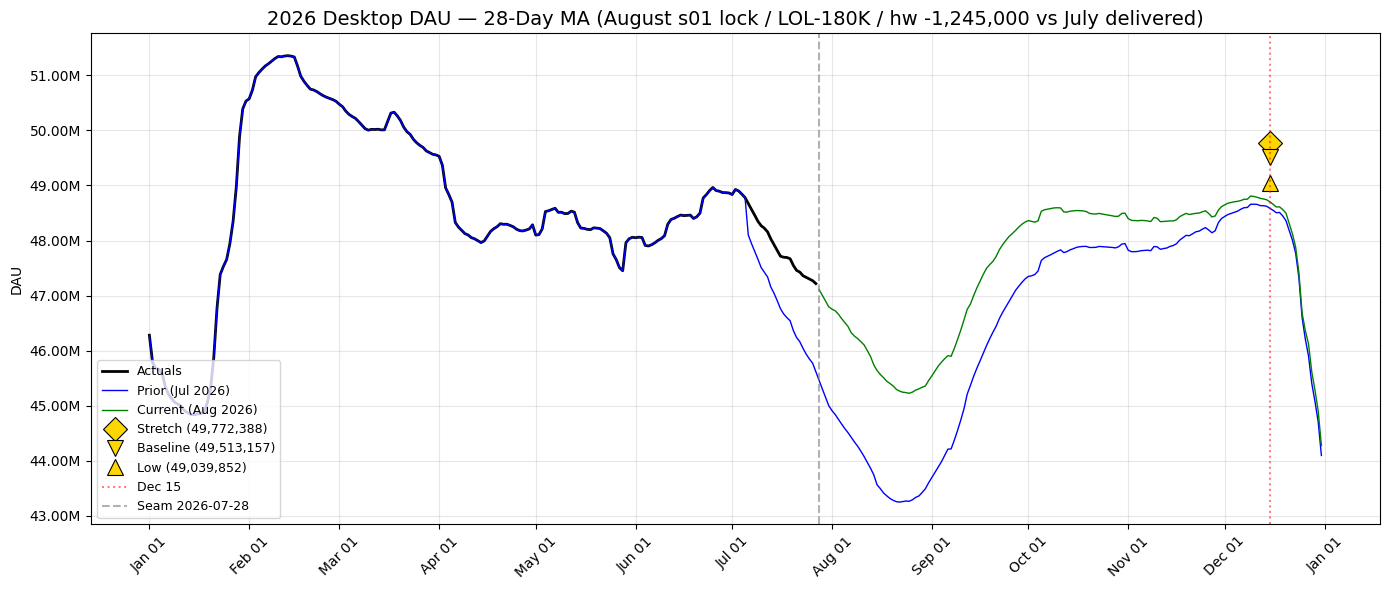

In [7]:
# [plot-desktop]
# Stakeholder Dec-15 benchmarks. These are the ASPIRATIONAL low/baseline/stretch markers originally
# set for the June cycle and reused unchanged in July; they are NOT August targets and no August
# target has been set. Kept only so the vertical scale is comparable with the June/July plots.
STAKEHOLDER_DESKTOP_LOW = 49_039_852
STAKEHOLDER_DESKTOP_BASELINE = 49_513_157
STAKEHOLDER_DESKTOP_STRETCH = 49_772_388


def render_desktop_plot(*, show_prior: bool, title: str, savename: str):
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(clip_display(desktop_actual_ma), label="Actuals", color="black", linewidth=2)
    if show_prior:
        ax.plot(clip_display(prev_desktop_ma), label="Prior (Jul 2026)", color="blue", linewidth=1)
    ax.plot(clip_forecast_only(desktop_ma), label="Current (Aug 2026)",
            color="green", linewidth=1)
    for value, marker, label in [
        (STAKEHOLDER_DESKTOP_STRETCH, "D", "Stretch"),
        (STAKEHOLDER_DESKTOP_BASELINE, "v", "Baseline"),
        (STAKEHOLDER_DESKTOP_LOW, "^", "Low"),
    ]:
        ax.plot(MEASUREMENT_DATE, value, marker=marker, color="gold",
                markersize=12, markeredgecolor="black", markeredgewidth=0.8,
                linestyle="None", label=f"{label} ({value:,})")
    ax.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5, label="Dec 15")
    ax.axvline(FORECAST_START, color="grey", linestyle="--", alpha=0.6,
               label=f"Seam {FORECAST_START.date()}")
    ax.set_title(title, fontsize=14)
    ax.set_ylabel("DAU")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
    ax.legend(loc="lower left", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    out = f"{PLOTS_DIR}/{savename}"
    fig.savefig(out, dpi=130)
    print(f"saved: {out}")
    plt.show()


render_desktop_plot(
    show_prior=True,
    title="2026 Desktop DAU — 28-Day MA (August s01 lock / LOL-180K / hw -1,245,000 vs July delivered)",
    savename="desktop_current_vs_july.png")


saved: data-official/2026-08/plots/desktop_current_only.png


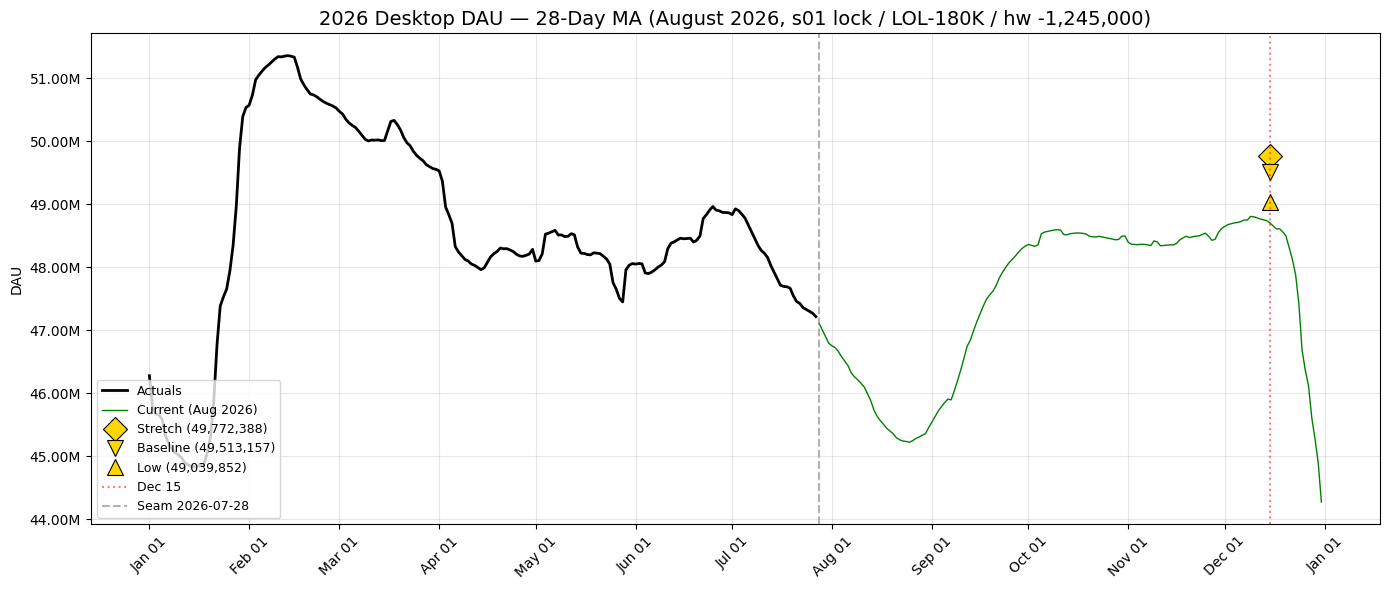

In [8]:
# [plot-desktop-current-only]
render_desktop_plot(
    show_prior=False,
    title="2026 Desktop DAU — 28-Day MA (August 2026, s01 lock / LOL-180K / hw -1,245,000)",
    savename="desktop_current_only.png")


In [9]:
# [desktop-dec15]
# Pinned historical measurements, post-headwind Dec-15 28d-MA. Every one is a value some build on disk
# produced; none is a target and nothing was tuned to any of them.
#   JULY_DELIVERED  -- data-official/2026-07/_index.md. The prior curve rebuilt below must reproduce it;
#                      a mismatch means the N-1 line is not what was delivered.
#   AUG_125K_OLD_HW -- the first August build: 125K LOL curve, headwind -1,345,000, this anchor and data.
#                      Superseded in place; number preserved in git commit 140412e.
#   LOL_125K_TO_180K -- derived residual from the 180K era (that build's Dec-15 was 48,672,970).
#   S01_RETUNE      -- MEASURED like-for-like in research/param-scans/summer-trough-v2/
#                      s01_canonical_desktop.ipynb: previous config vs s01, BOTH on the 180K curve, so
#                      the model config is the only difference. Trough +1,359,887 for this +5,642.
#   LOL_180K_TO_200K -- MEASURED between two frozen s01 builds whose sidecars differ in exactly the `l`
#                      spec sha1 (e23a6267 -> e8b4a218) and in nothing else: identical model_config,
#                      identical `o` spec, same seam, same raw BQ cache, and zero diff across every
#                      pipeline module between their two commits. Verified 2026-07-29.
JULY_DELIVERED_DESKTOP_DEC15 = 48_585_483
AUG_125K_OLD_HW = 48_520_714
LOL_125K_TO_180K = 52_256
S01_RETUNE = 5_642
LOL_180K_TO_200K = 25_348

# Raw curve delta at Dec-15 between the active LOL curve and the 125K curve the first build used. Both
# are at their ceilings by Dec-15, so this is just the difference of ceilings. Read from the files
# rather than hardcoded, so it follows a cap change automatically.
_lol_dir = "data-official/2026-08/launch_on_login"
_active_spec = json.load(open(f"{_lol_dir}/lol.json"))
_active_curve = pd.read_parquet(f"{_lol_dir}/{_active_spec['data_file']}")["lol_lift_daily"]
_baseline_curve = pd.read_parquet(f"{_lol_dir}/lol_tailwind.2026-06-29.parquet")["lol_lift_daily"]
LOL_CURVE_DELTA = _active_curve.loc[MEASUREMENT_DATE] - _baseline_curve.loc[MEASUREMENT_DATE]

desktop_series = {
    "Actuals": desktop_actual_ma,
    "Prior (Jul 2026 delivered)": prev_desktop_ma,
    "Current (Aug 2026, s01)": desktop_ma,
}

header = f"{'Series':<32s} {'Dec 15 28-day MA':>18s} {'Aug trough min':>18s}"
print(header)
print("-" * len(header))
for name, s in desktop_series.items():
    val = s.get(MEASUREMENT_DATE, np.nan)
    summer = s.loc[FORECAST_START:pd.Timestamp("2026-10-15")].dropna()
    trough = summer.min() if len(summer) else np.nan
    print(f"{name:<32s} {(f'{val:,.0f}' if pd.notna(val) else 'N/A'):>18s} "
          f"{(f'{trough:,.0f}' if pd.notna(trough) else 'N/A'):>18s}")

prior_recomputed = prev_desktop_ma.get(MEASUREMENT_DATE, np.nan)
drift = prior_recomputed - JULY_DELIVERED_DESKTOP_DEC15
print(f"\nPrior-curve reproduction check: recomputed {prior_recomputed:,.0f} vs "
      f"delivered {JULY_DELIVERED_DESKTOP_DEC15:,.0f} (drift {drift:+,.0f})")
assert abs(drift) < 1000, (
    f"July's delivered desktop Dec-15 does not reproduce (drift {drift:+,.0f}). The prior comparison "
    f"line is not the delivered July forecast -- investigate before quoting any delta."
)

# --- Attribution ledger -------------------------------------------------------------------------
# FIVE changes separate July's delivered number from this one, and all five are attributed. The
# components are PINNED rather than recomputed here, each measured against a build that differs from its
# comparator in exactly one input -- see the constants above for which build and which input.
#
# Why pinned and not loaded: every intermediate build's parquet is gitignored and is archived to GCS at
# button-down, so a ledger that loaded them would break for anyone without the blobs. Pinning also makes
# this ledger CHECKABLE: the steps no longer close by construction, so the closure assertion below is a
# real test that this parquet is the build the constants describe. A residual ledger cannot test itself.
#
# HISTORICAL BUILDS ARE LOCKED. None of the comparison points above was re-run to produce these numbers;
# each was differenced against an artifact that already existed. Do not rebuild one to "improve" a step.
current = desktop_ma.get(MEASUREMENT_DATE, np.nan)
headwind_now = net_adjustments["desktop"].get(MEASUREMENT_DATE, np.nan)
headwind_july = prev_net_adjustments["desktop"].get(MEASUREMENT_DATE, np.nan)
headwind_step = headwind_now - headwind_july
data_refresh_effect = AUG_125K_OLD_HW - JULY_DELIVERED_DESKTOP_DEC15

ledger = [
    ("July delivered (125K LOL, hw -1,345,000, 07-06 anchor)", None, JULY_DELIVERED_DESKTOP_DEC15),
    ("+ data refresh to the 07-28 anchor", data_refresh_effect, AUG_125K_OLD_HW),
    ("+ LOL ceiling 125,000 -> 180,000 (derived residual)", LOL_125K_TO_180K,
     AUG_125K_OLD_HW + LOL_125K_TO_180K),
    (f"+ Win10 headwind {headwind_july:,.0f} -> {headwind_now:,.0f}", headwind_step,
     AUG_125K_OLD_HW + LOL_125K_TO_180K + headwind_step),
    ("+ desktop model retune to s01 (measured, both @180K)", S01_RETUNE,
     AUG_125K_OLD_HW + LOL_125K_TO_180K + headwind_step + S01_RETUNE),
    ("+ LOL ceiling 180,000 -> 200,000 (measured, both s01)", LOL_180K_TO_200K,
     AUG_125K_OLD_HW + LOL_125K_TO_180K + headwind_step + S01_RETUNE + LOL_180K_TO_200K),
]
print(f"\nDec-15 desktop 28d-MA attribution ledger (all post-headwind):")
w = max(len(r[0]) for r in ledger)
for label, step, running in ledger:
    print(f"  {label:<{w}}  {(f'{step:+,.0f}' if step is not None else ''):>10}  ->  {running:>12,.0f}")

# CLOSURE CHECK -- a real test, because every step is pinned independently of this parquet.
ledger_total = ledger[-1][2]
closure = current - ledger_total
print(f"\nLedger closes to {ledger_total:,.0f} vs measured {current:,.0f} (residual {closure:+,.0f})")
assert abs(closure) < 1, (
    f"the attribution ledger does not close: pinned steps sum to {ledger_total:,.0f} but this build "
    f"reads {current:,.0f} (residual {closure:+,.0f}). Either a constant above is stale or this parquet "
    f"is not the build they describe. Do not quote the attribution until this is resolved."
)

# Physical plausibility of the two LOL steps taken together, against the raw curve change they respond
# to. The curve rose +LOL_CURVE_DELTA/day from July's 125K ceiling; a bidirectional overlay should pass
# through most but not wildly more than that. Near-zero would mean the add-back leg never ran; far above
# 1 would mean the training subtraction is reshaping the trend unexpectedly.
lol_total = LOL_125K_TO_180K + LOL_180K_TO_200K
pass_through = lol_total / LOL_CURVE_DELTA
print(f"LOL pass-through: curve +{LOL_CURVE_DELTA:,.0f}/day at Dec-15, realised {lol_total:+,.0f} "
      f"({pass_through * 100:.0f}% of the raw curve change)")
assert 0.5 < pass_through < 1.5, (
    f"LOL pass-through {pass_through:.2f}x is outside the plausible 0.5-1.5x band "
    f"(curve {LOL_CURVE_DELTA:+,.0f}/day, realised {lol_total:+,.0f})."
)

# The ceiling's effect is CONFIG-DEPENDENT, which is why the two LOL steps are not interchangeable:
# 180K -> 200K is worth +25,348 under s01 but only ~+7,211 under the previous flatter config, because
# `l` is bidirectional and s01's 2.1x changepoint flexibility responds far more to a modified training
# series. Never treat a ceiling change as a level shift.

# --- The retune's whole point: a big trough gain for a small Dec-15 move ---
DEC15_BUDGET = 50_000
print(f"\nRetune (measured @180K): trough +1,359,887 for {S01_RETUNE:+,.0f} at Dec-15 "
      f"({abs(S01_RETUNE)/DEC15_BUDGET*100:.0f}% of the +-{DEC15_BUDGET:,} budget)")
assert abs(S01_RETUNE) <= DEC15_BUDGET, \
    f"the retune moves Dec-15 by {S01_RETUNE:+,.0f}, outside the +-{DEC15_BUDGET:,} budget"

# This build's own trough, checked as an absolute band rather than against a superseded build.
cur_summer = desktop_ma.loc[FORECAST_START:pd.Timestamp("2026-10-15")].dropna()
print(f"This build's trough: {cur_summer.min():,.0f} on {cur_summer.idxmin().date()} "
      f"(target band 45-46M; pre-retune builds troughed near 43.8M)")
assert 45_000_000 <= cur_summer.min() <= 46_000_000, (
    f"summer trough {cur_summer.min():,.0f} is outside the 45-46M band the s01 retune was adopted to "
    f"reach -- this parquet is probably not the s01 build")

print(f"Net vs July delivered: {current - JULY_DELIVERED_DESKTOP_DEC15:+,.0f} DAU "
      f"({(current / JULY_DELIVERED_DESKTOP_DEC15 - 1) * 100:+.2f}%)")


Series                             Dec 15 28-day MA     Aug trough min
----------------------------------------------------------------------
Actuals                                         N/A                N/A
Prior (Jul 2026 delivered)               48,585,483         43,246,576
Current (Aug 2026, s01)                  48,703,960         45,223,249

Prior-curve reproduction check: recomputed 48,585,483 vs delivered 48,585,483 (drift +0)

Dec-15 desktop 28d-MA attribution ledger (all post-headwind):
  July delivered (125K LOL, hw -1,345,000, 07-06 anchor)              ->    48,585,483
  + data refresh to the 07-28 anchor                         -64,769  ->    48,520,714
  + LOL ceiling 125,000 -> 180,000 (derived residual)        +52,256  ->    48,572,970
  + Win10 headwind -1,345,000 -> -1,245,000                 +100,000  ->    48,672,970
  + desktop model retune to s01 (measured, both @180K)        +5,642  ->    48,678,612
  + LOL ceiling 180,000 -> 200,000 (measured, both s01)  

saved: data-official/2026-08/plots/mobile_august_vs_july.png


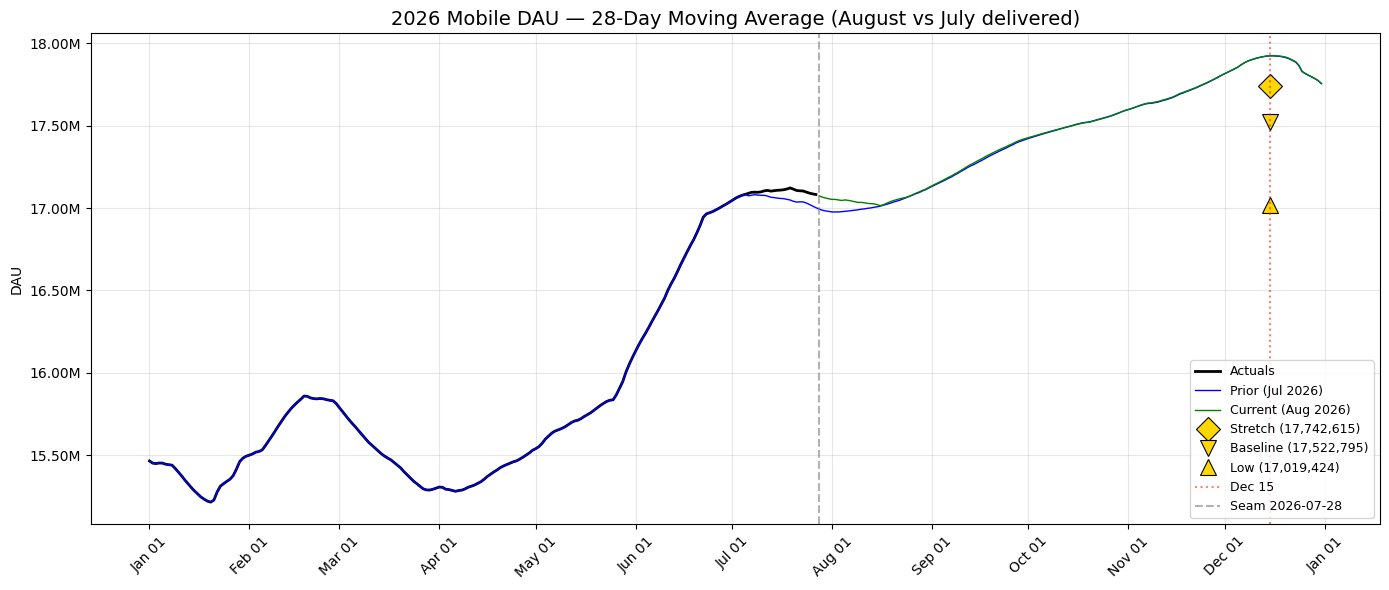

In [10]:
# [plot-mobile]
# Stakeholder Dec-15 mobile benchmarks. As with desktop, these are the June-cycle aspirational
# markers reused in July, NOT August targets. Kept for scale comparability only.
STAKEHOLDER_MOBILE_LOW = 17_019_424
STAKEHOLDER_MOBILE_BASELINE = 17_522_795
STAKEHOLDER_MOBILE_STRETCH = 17_742_615


def render_mobile_plot(*, show_prior: bool, title: str, savename: str):
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(clip_display(mobile_actual_ma), label="Actuals", color="black", linewidth=2)
    if show_prior:
        ax.plot(clip_display(prev_mobile_ma), label="Prior (Jul 2026)", color="blue", linewidth=1)
    # Mobile is UNCHANGED by the LOL rebuild -- `l` is desktop-only, so this is the same mobile run as
    # the 125K baseline. Any movement vs July is the data refresh alone.
    ax.plot(clip_forecast_only(mobile_ma, MOBILE_FORECAST_START),
            label="Current (Aug 2026)", color="green", linewidth=1)
    for value, marker, label in [
        (STAKEHOLDER_MOBILE_STRETCH, "D", "Stretch"),
        (STAKEHOLDER_MOBILE_BASELINE, "v", "Baseline"),
        (STAKEHOLDER_MOBILE_LOW, "^", "Low"),
    ]:
        ax.plot(MEASUREMENT_DATE, value, marker=marker, color="gold",
                markersize=12, markeredgecolor="black", markeredgewidth=0.8,
                linestyle="None", label=f"{label} ({value:,})")
    ax.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5, label="Dec 15")
    ax.axvline(MOBILE_FORECAST_START, color="grey", linestyle="--", alpha=0.6,
               label=f"Seam {MOBILE_FORECAST_START.date()}")
    ax.set_title(title, fontsize=14)
    ax.set_ylabel("DAU")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
    ax.legend(loc="lower right", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    out = f"{PLOTS_DIR}/{savename}"
    fig.savefig(out, dpi=130)
    print(f"saved: {out}")
    plt.show()


render_mobile_plot(
    show_prior=True,
    title="2026 Mobile DAU — 28-Day Moving Average (August vs July delivered)",
    savename="mobile_august_vs_july.png")


saved: data-official/2026-08/plots/mobile_august_only.png


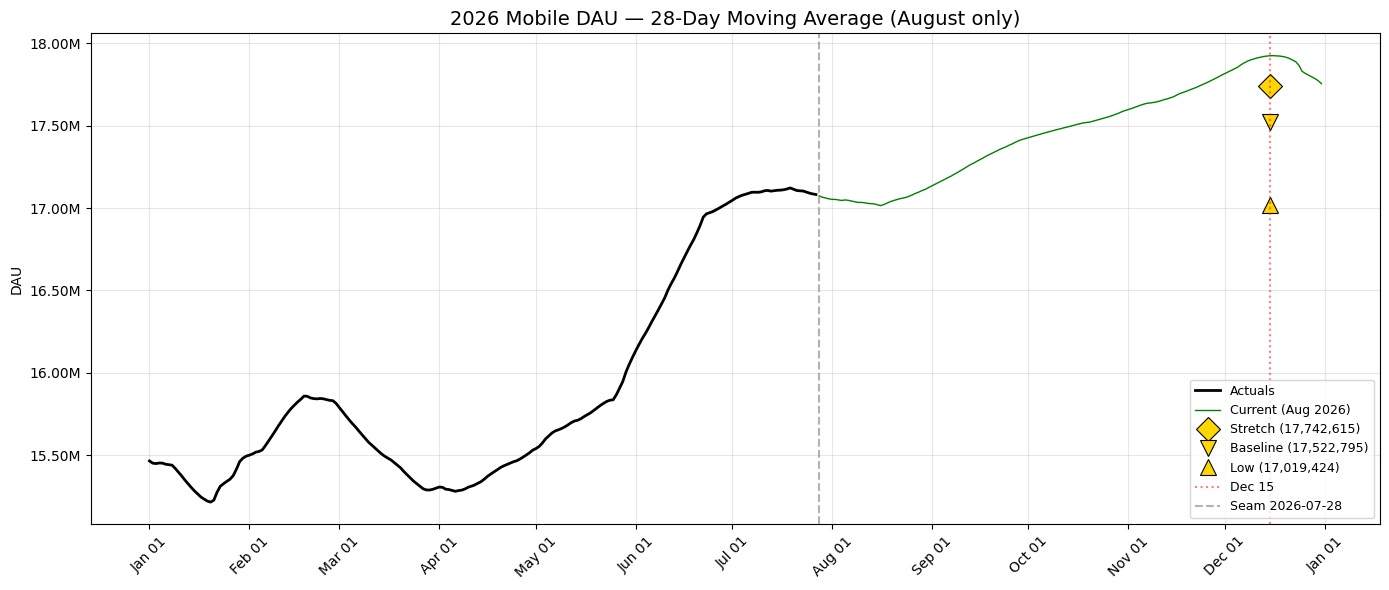

In [11]:
# [plot-mobile-current-only]
render_mobile_plot(
    show_prior=False,
    title="2026 Mobile DAU — 28-Day Moving Average (August only)",
    savename="mobile_august_only.png")


saved: data-official/2026-08/plots/mobile_ex_iran_august_vs_july.png


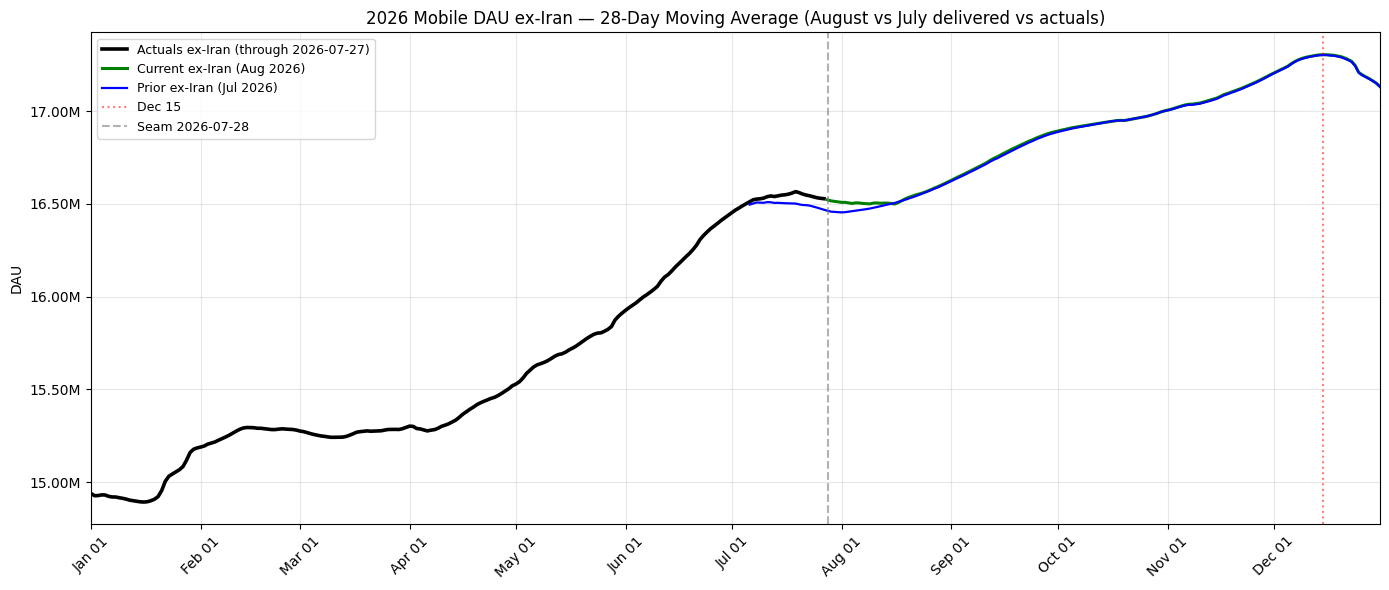


Dec-15 ex-Iran 28d MA:  August 17,303,955  |  July 17,302,425  |  delta +1,530


In [12]:
# [plot-mobile-ex-iran]
# ALL-MOBILE EXCLUDING Iran (28d MA): August vs July delivered vs actuals.
# Mobile is unaffected by the desktop-only LOL rebuild; this is the data-refresh comparison.
# Removing Iran strips the post-shutdown reconnection bounce so the underlying trajectories are
# directly comparable. Iran is still in the headline (incl-Iran) curves above.
#
# NOTE ON METHOD: July's notebook took its ex-Iran PRIOR line from a precomputed column in
# june_canonical_curves.csv. July's own canonical CSV has no ex-Iran columns, so both curves here are
# derived from their respective parquets (ALL minus IR), each with its own headwind and its own seam.
# That is self-consistent and avoids depending on a column that does not exist.


def ex_iran_ma(parquet_path, seam, require_state, adjustments):
    """World-minus-Iran mobile DAU as a seam-smoothed, headwind-adjusted 28d MA.

    Returns (forecast_ma, actual_ma). The actual leg uses training rows only and the plain
    trailing MA; the forecast leg uses display_ma plus the mobile headwind from `adjustments`.
    """
    df, _ = load_forecast(parquet_path, require_state=require_state)
    df["target_date"] = pd.to_datetime(df["target_date"])

    def series(country, data_type=None):
        mask = ((df.data_source == "glean_mobile") & (df.country == country)
                & (df.app_name == "ALL MOBILE") & (df.segment == "{}"))
        rows = df.loc[mask]
        if data_type is not None:
            rows = rows[rows.data_type == data_type]
        return rows.set_index("target_date").sort_index()["dau"]

    ex_ir = series("ALL").subtract(series("IR"), fill_value=0.0)
    forecast_ma = apply_net_adjustment(
        display_ma(ex_ir.index.to_series(), ex_ir, seam),
        adjustments, "mobile", forecast_start=seam)

    act = series("ALL", "training").subtract(series("IR", "training"), fill_value=0.0)
    return forecast_ma, daily_to_28ma(act.index.to_series(), act)


aug_exir_ma, act_exir_ma = ex_iran_ma(
    MOBILE_FORECAST_PATH, MOBILE_FORECAST_START, ["m"], net_adjustments)
jul_exir_ma, _ = ex_iran_ma(
    PREV_FORECAST_MOBILE_PATH, PREV_FORECAST_START, ["m"], prev_net_adjustments)

SEAM = MOBILE_FORECAST_START - pd.Timedelta(days=1)   # 2026-07-27, last actual day

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(act_exir_ma.loc[DISPLAY_START:SEAM].index, act_exir_ma.loc[DISPLAY_START:SEAM],
        color="black", linewidth=2.6, label=f"Actuals ex-Iran (through {SEAM.date()})")
ax.plot(aug_exir_ma.loc[MOBILE_FORECAST_START:DISPLAY_END].index,
        aug_exir_ma.loc[MOBILE_FORECAST_START:DISPLAY_END],
        color="green", linewidth=2.2, label="Current ex-Iran (Aug 2026)")
ax.plot(jul_exir_ma.loc[PREV_FORECAST_START:DISPLAY_END].index,
        jul_exir_ma.loc[PREV_FORECAST_START:DISPLAY_END],
        color="blue", linewidth=1.6, label="Prior ex-Iran (Jul 2026)")
ax.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5, label="Dec 15")
ax.axvline(MOBILE_FORECAST_START, color="grey", linestyle="--", alpha=0.6,
           label=f"Seam {MOBILE_FORECAST_START.date()}")
ax.set_title("2026 Mobile DAU ex-Iran — 28-Day Moving Average "
             "(August vs July delivered vs actuals)")
ax.set_ylabel("DAU")
ax.set_xlim(DISPLAY_START, DISPLAY_END)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.legend(loc="upper left", fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
out = f"{PLOTS_DIR}/mobile_ex_iran_august_vs_july.png"
fig.savefig(out, dpi=130)
print(f"saved: {out}")
plt.show()

print(f"\nDec-15 ex-Iran 28d MA:  August {aug_exir_ma.get(MEASUREMENT_DATE, np.nan):,.0f}  |  "
      f"July {jul_exir_ma.get(MEASUREMENT_DATE, np.nan):,.0f}  |  "
      f"delta {aug_exir_ma.get(MEASUREMENT_DATE, np.nan) - jul_exir_ma.get(MEASUREMENT_DATE, np.nan):+,.0f}")


In [13]:
# [mobile-dec15]
# July's DELIVERED mobile Dec-15 28d-MA, from data-official/2026-07/_index.md. Same reproduction
# check as desktop: if the prior curve does not rebuild to the delivered number, the deltas are junk.
#
# Mobile is UNCHANGED by the LOL rebuild -- `l` applies to legacy_desktop only, so this is the same
# mobile parquet the 125K baseline used. Its Dec-15 was 17,924,607; it should still be exactly that.
JULY_DELIVERED_MOBILE_DEC15 = 17_923_869
AUG_BASELINE_MOBILE_DEC15 = 17_924_607

mobile_series = {
    "Actuals": mobile_actual_ma,
    "Prior (Jul 2026 delivered)": prev_mobile_ma,
    "Current (Aug 2026)": mobile_ma,
}

header = f"{'Series':<30s} {'Dec 15 28-day MA':>18s}"
print(header)
print("-" * len(header))
for name, s in mobile_series.items():
    val = s.get(MEASUREMENT_DATE, np.nan)
    val_str = f"{val:,.0f}" if pd.notna(val) else "N/A"
    print(f"{name:<30s} {val_str:>18s}")

prior_recomputed = prev_mobile_ma.get(MEASUREMENT_DATE, np.nan)
drift = prior_recomputed - JULY_DELIVERED_MOBILE_DEC15
print(f"\nPrior-curve reproduction check: recomputed {prior_recomputed:,.0f} vs "
      f"delivered {JULY_DELIVERED_MOBILE_DEC15:,.0f} (drift {drift:+,.0f})")
assert abs(drift) < 1000, (
    f"July's delivered mobile Dec-15 does not reproduce (drift {drift:+,.0f}). "
    f"Investigate before quoting any August-vs-July delta."
)

current = mobile_ma.get(MEASUREMENT_DATE, np.nan)
print(f"\nAugust vs July delivered: {current - JULY_DELIVERED_MOBILE_DEC15:+,.0f} DAU "
      f"({(current / JULY_DELIVERED_MOBILE_DEC15 - 1) * 100:+.2f}%)")

# Mobile must be untouched by a desktop-only overlay change. If this drifts, either the mobile parquet
# was regenerated when it should not have been, or `l` is leaking outside legacy_desktop.
mobile_drift = current - AUG_BASELINE_MOBILE_DEC15
print(f"vs the 125K-baseline mobile run:  {mobile_drift:+,.0f} DAU (expected exactly 0 -- `l` is desktop-only)")
assert abs(mobile_drift) < 1, (
    f"Mobile Dec-15 moved by {mobile_drift:+,.0f} after a DESKTOP-only overlay change. Either the "
    f"mobile forecast was rebuilt unintentionally or the `l` overlay is leaking beyond legacy_desktop."
)


Series                           Dec 15 28-day MA
-------------------------------------------------
Actuals                                       N/A
Prior (Jul 2026 delivered)             17,923,869
Current (Aug 2026)                     17,924,607

Prior-curve reproduction check: recomputed 17,923,869 vs delivered 17,923,869 (drift -0)

August vs July delivered: +738 DAU (+0.00%)
vs the 125K-baseline mobile run:  +0 DAU (expected exactly 0 -- `l` is desktop-only)


In [14]:
# [dec15-summary]
# Headline table: August baseline vs July delivered at the Dec-15 2026 measurement date, 28-day MA.
# ALL = Desktop + Mobile (the two platforms are disjoint populations, so a plain sum is correct).
rows = []
for label, current, prior in [
    ("Desktop", desktop_ma.get(MEASUREMENT_DATE, np.nan), prev_desktop_ma.get(MEASUREMENT_DATE, np.nan)),
    ("Mobile", mobile_ma.get(MEASUREMENT_DATE, np.nan), prev_mobile_ma.get(MEASUREMENT_DATE, np.nan)),
]:
    rows.append((label, current, prior))
rows.append((
    "ALL",
    sum(r[1] for r in rows),
    sum(r[2] for r in rows),
))

label_w = max(len(r[0]) for r in rows)
col_w = 20

print("Dec 15, 2026 — 28-day moving average")
print("(August = s01 DESKTOP RETUNE + July's mobile lock, data through 2026-07-27, LOL ceiling 125K -> 200K,")
print(" Win10 headwind desktop anchor -1,345,000 -> -1,245,000 [ALTERNATE, under evaluation] and the")
print(" ramp re-anchored to start at the seam rather than 2026-04-01 [no effect on Dec-15; lifts the")
print(" near term]. The `o` and `m` overlays are still unchanged stale carry-forwards from July.)")
print()
header = (f"{'Series':<{label_w}}  {'Aug current':>{col_w}}  {'Jul delivered':>{col_w}}  "
          f"{'Delta':>{col_w}}  {'Delta %':>9}")
print(header)
print("-" * len(header))
for label, current, prior in rows:
    print(f"{label:<{label_w}}  {current:>{col_w},.0f}  {prior:>{col_w},.0f}  "
          f"{current - prior:>{col_w},.0f}  {(current / prior - 1) * 100:>8.2f}%")

# Also report the near-horizon summer trough, the KPI the aug22-retune search was built around.
# Reported here for visibility only -- no target is being asserted and nothing was tuned to it.
TROUGH_DATE = pd.Timestamp("2026-08-22")
print(f"\nNear-horizon check — {TROUGH_DATE.date()} summer trough (28d MA, post-headwind):")
for label, s in [("Desktop", desktop_ma), ("Mobile", mobile_ma)]:
    print(f"  {label:<8s} {s.get(TROUGH_DATE, np.nan):,.0f}")
print(f"  {'ALL':<8s} {desktop_ma.get(TROUGH_DATE, np.nan) + mobile_ma.get(TROUGH_DATE, np.nan):,.0f}")


Dec 15, 2026 — 28-day moving average
(August = s01 DESKTOP RETUNE + July's mobile lock, data through 2026-07-27, LOL ceiling 125K -> 200K,
 Win10 headwind desktop anchor -1,345,000 -> -1,245,000 [ALTERNATE, under evaluation] and the
 ramp re-anchored to start at the seam rather than 2026-04-01 [no effect on Dec-15; lifts the
 near term]. The `o` and `m` overlays are still unchanged stale carry-forwards from July.)

Series            Aug current         Jul delivered                 Delta    Delta %
------------------------------------------------------------------------------------
Desktop            48,703,960            48,585,483               118,476      0.24%
Mobile             17,924,607            17,923,869                   738      0.00%
ALL                66,628,567            66,509,352               119,215      0.18%

Near-horizon check — 2026-08-22 summer trough (28d MA, post-headwind):
  Desktop  45,263,042
  Mobile   17,056,561
  ALL      62,319,604


## Caveats — read before quoting any number above

This is **not a delivered forecast**. The desktop model has been retuned, `l` refreshed and the headwind
anchor attenuated; `o` and `m` are still stale carry-forwards from July.

### Five changes this cycle — four move the KPI, one does not

| lever | change | Dec-15 effect | basis |
|---|---|--:|---|
| `l` LOL ceiling | 125,000 → 180,000/day | +52,256 | extrapolation judgement; measurement stops 2026-06-23 |
| `l` LOL ceiling again | 180,000 → 200,000/day | +25,348 | same judgement, taken further; least conservative of the three built |
| `h` Win10 anchor | −1,345,000 → −1,245,000 | +100,000 exactly | calibration judgement; never validated against telemetry |
| `h` ramp start | 2026-04-01 → seam (2026-07-28) | **0** | convention correction; measured, see below |
| | | **+177,604** | |

Against a data refresh that moved desktop **−64,769**, the judgement-based adjustments together add
+177,604 — so the sign of the August-vs-July headline is set by the discretionary levers, not by what the
fresher data said. That is not evidence of anything wrong: both changes have a documented rationale, and
the LOL ceiling was arguably too conservative before (July's 125K clamped *below* the last clean
measurement of 130,296). But it does mean **the headline should not be described as "what the data now
says."** It is the model plus two upward judgement calls, and the data component alone pointed slightly
down.

The **ramp re-anchoring is in a different category** and is excluded from that total because its Dec-15
effect is exactly zero. It is a correction of a measured double-count, not a judgement call about
magnitude — see below. It does lift the near-term a lot (+569,419 at the seam, +467,737 at Aug-22,
+305,046 at Oct-1), so **near-horizon numbers from this build are not comparable to earlier builds**,
while Dec-15 is.

Neither lever has a validation artifact yet. For `h` the test is tractable and queued
(`research/headwinds/`); for `l` the measurement window is permanently closed, so no test exists — only
the convolution-model cross-check.

### The desktop model was retuned — this is now the largest change of the cycle

Desktop is locked to **s01** (`regime=multiplicative, cps=0.1849, cpr=0.734, recent_weeks=17,
n_changepoints=35`), replacing July's parameter lock. It lifts the summer trough **+1,359,887**
(43,833,674 → 45,193,561) while moving Dec-15 only **+5,642** — 11% of the ±50,000 budget that was the
binding constraint. It also improves the seam handoff derivative substantially (model kink **−19,702/day
vs −74,237**, 73% smaller). Delta evidence:
`research/param-scans/summer-trough-v2/s01_canonical_desktop.ipynb`.

Two things to keep straight about those numbers. **They are measured with both sides on the 180K LOL
curve**, which is what makes the model config the only difference — so 45,193,561 is the *180K* s01
trough, not this build's. **This build troughs at 45,223,249** (the extra +29,688 is the 200K ceiling).
And the kink figures were **re-measured 2026-07-29** after the seam trend-estimator fix; pre-fix they
read −20,604 vs −72,593. The ranking never changed, but the magnitudes were contaminated by the
estimator defect, so quote the values above.

Four things about it that a reader should weigh:

**1. It is a materially more flexible trend model than what has ever shipped.** `cps` is 2.1× July's,
`ncp` 1.4×, `cpr` 0.734 vs 0.65. The objection raised against tuning holiday parameters — local
flexibility compensating for missing structure — applies here in weaker form. It is more defensible
because trend knobs are global rather than regional, but it is not free of the concern.

**2. It sits on a bend, not a plateau.** `changepoint_range` is the dominant lever (+102,862 trough per
+10% of center) and its **curvature is 2.4× its own slope**, so the local gradient must not be
extrapolated. Three other knobs are worse (`sps` 11.1×, `recent_weeks` 6.0×). Small parameter moves near
this point are not safely predictable; measure, do not extrapolate.

**3. Autumn is unvalidated and materially changed.** The s01 Oct–Nov plateau runs ~250–400K above the
pre-retune shape. It converges by Dec-15 because Dec-15 is the constrained point, not because the model
was asked to be right there. Anyone consuming autumn numbers is getting a shape they have not
reviewed.

**4. Holiday parameters were excluded on principle, not on evidence.** They produce strictly local
effects, so using them to move a whole-season quantity is compensating for an overall trend with a small
regional fix. The gradient measured `holiday_max_radius` as the **second-largest** trough lever and
`holiday_threshold` as the best trough:Dec ratio; both were declined anyway.
`scripts/run_trend_only_grid.py` refuses holiday overrides, and `[load-parquets]` asserts the four knobs
are at defaults, so the policy cannot lapse silently.

A 21-probe trend-only grid found only one config beating s01 inside the Dec-15 band (`ncp=42`, trough
45,233,021, +39,460) at a Dec-15 drift of +36,553 — 73% of the budget for a 0.09% gain. Not taken.
Full frontier: `research/param-scans/summer-trough-v2/trend_only_report.html`.

### The seam step was a display artifact, and it is now FIXED

**Superseded 2026-07-29.** This section previously documented an unexplained **+102,595 upward step**
at the seam as a known, open display artifact. It has since been diagnosed and fixed, so the numbers
below describe the *old* behaviour and the curves in this notebook now reflect the *fixed* one.

The cause was `reconstruct_matched_daily`, which deseasonalized the forecast with a 7-day *centered*
rolling mean computed on the **forecast only**. At the seam that window has no left half, and
`min_periods=4` silently accepted the first four forecast days — Tue/Wed/Thu/Fri, all weekdays, no
weekend — the maximally biased sample for a weekly deseasonalization. The trend read ~10% high, was
then multiplied by the Tuesday day-of-week factor as though it still needed deseasonalizing, and the
first rebuilt day landed **+5,921,427** above the model's own value: **+211,480 on a 28-day MA**.

**The fix (`Fix A`) deseasonalizes before averaging** — each forecast day is divided by the forecast's
own day-of-week profile *before* smoothing, so window composition stops mattering. It lives in
`src/mozaic_daily/seam_ma.py`, which this notebook now imports.

All the diagnosis figures above (+102,595, +5,921,427, +211,480) were measured on the **180K** build,
which is what was on the published chart at the time; they are historical. On the 180K build the fix took
the display distortion from **211,480 → 116 DAU** and the seam step from +102,595 to −108,769, against a
plain 28-day MA step of −108,884. **This build (200K) reads a seam step of −107,445 against a plain
−107,547 — a residual distortion of +102 DAU.**

**The published curve now steps DOWN at the seam, and that is correct.** The old upward step was
masking a genuine decline — the model's own 28-day MA falls 108,884 that day. Read the seam as a bend,
not a break: the actuals MA was already falling (−29,967 then −53,163 into the seam).

**Headline numbers did not move.** Dec-15 and every date from seam+27 onward are byte-identical to
before the fix, on both platforms, over 495 dates each — `display_ma` overwrites that region with the
forecast-only MA, which no reconstruction change can reach. Asserted in
`data-official/2026-08/seam_fix_before_after.ipynb`.

Two things from the old write-up worth keeping, because both were reasoning traps:

- **A near-zero seam step is not evidence of a good curve.** The pre-retune August build read +5,157 at
  the seam because a −201,501 plain-MA step and a +206,658 reconstruction bias happened to cancel; July's
  delivered +2,789 was the same accident (bias +191,978 against a real −189,189). Both looked continuous
  for the same wrong reason.
- **The old test tolerance (`step/level < 0.02`) is why nothing failed** — it was calibrated when the
  step happened to be +5,157, and 0.22% sits well inside it. It is gone; `tests/test_seam_ma.py` now
  scores against analytically known values, sweeps the seam across all seven weekdays, and carries a
  canary that fails if the suite ever stops catching this defect class.

Full record, including the two variants scored and rejected: `research/ma-seam-turbulence/LOG.md`
§ Fix A. Diagnosis walkthrough: `research/ma-seam-turbulence/seam_step_diagnosis.ipynb`.

### Overlay freshness

| overlay | state | detail |
|---|---|---|
| `l` launch-on-login | **REFRESHED 2026-07-29; ceiling raised again to 200K** | 200,000 ceiling, reached 2026-07-19. Measured to 2026-06-23, extrapolated after. The extrapolation is unavoidable, not laziness — see below. |
| `o` MozillaOnline | **STALE (~5 weeks)** | Brad's curve, built from data through late June. Deliberately conservative: July recorded actuals already running **ahead** of the ramp. Under-subtraction leaves migration signal in the trend. |
| `m` marketing lift | **STALE (~4 weeks)** | June-anchored Fenix paid curve. Whether it over- or under-states depends on how July's actual paid delivery tracked the marketing outlook — unknown until re-measured. |

For the two stale overlays the bidirectional appliers subtract the curve from training rows before
mozaic, so for the 2026-06-29 → 2026-07-27 rows what gets subtracted is the curve's **modelled** value,
not a measured one. Where reality diverged, Prophet absorbs the residual into trend.

### The LOL measurement window is closed permanently

Everything in the `l` curve after **2026-06-23** is extrapolation by construction. Contamination begins
2026-06-24: the holdback control group received the feature, so the counterfactual is gone. No fresh
telemetry can extend the clean window — querying recent data shows the excess "collapsing," which is an
artifact of the control being treated, not a decay. **Do not attempt to re-measure this.**

**The ceiling is a judgement, not a measurement, and the evidence cannot discriminate between the
candidates.** Measured data stops at 130,296 on 2026-06-23. Every ceiling tried this cycle sits above
that and is reached *after* the measurement ends, so 125,000 / 165,000 / 180,000 / 200,000 all fit the
observed data equally well — they differ only in how far the unvalidated ~19K/wk rise is projected:

| ceiling | reached | vs measured last clean value | status |
|---|---|--:|---|
| 125,000 (July) | 2026-06-19 | −5,296 (clamped *below* measurement) | superseded |
| 165,000 | 2026-07-06 | +34,704 | on disk |
| 180,000 | 2026-07-12 | +49,704 | superseded by the 200K switch |
| **200,000 (current)** | **2026-07-19** | **+69,704** | active |

An independent convolution model of the same effect
(`~/work/launch-on-login/dau_model_convolution.ipynb`) lands near 220,000/day, so the active 200,000
still carries a ~20K/day haircut against it — the smallest of the three built (180,000 was ~40K, 165,000
~55K), i.e. **200K is the least conservative choice available**. But "between two unvalidated estimates"
is the honest description of the current position, not "measured."

The curve is **not strictly monotone** — six small downward steps inside the measured window (largest
−1,207, ≈1% of level) are day-of-week residue in the 7d-MA, four of which were already present in the
125K curve. That is smoothing noise, not a modelled drop-off; it was left measurement-faithful rather
than smoothed. From 2026-06-24 onward the curve is strictly non-decreasing.

### The Win10 headwind anchor is an unvalidated judgement that has now moved four times

Desktop is at **−1,245,000** at the Dec-15 anchor — an **alternate value under evaluation**, attenuated
+100,000 from July's −1,345,000. Mobile is unchanged at −27,162.

The reasoning is the same each cycle: `adj-h` carries the part of the Win10 migration decline that
Prophet has *not* learned from data, so as the decline shows up in actuals the exogenous anchor should
shrink or it double-counts. June concluded this, July acted on it (−1,420,000 → −1,370,000 → −1,345,000),
and this cycle continues it. **But note the sequence** — four successive attenuations, each justified
the same way, each raising the reported number:

| cycle | desktop anchor | step | cumulative vs June |
|---|--:|--:|--:|
| June delivered | −1,420,000 | — | — |
| July, first pass | −1,370,000 | +50,000 | +50,000 |
| July delivered | −1,345,000 | +25,000 | +75,000 |
| August, first pass | −1,295,000 | +50,000 | +125,000 |
| **August current (alternate)** | **−1,245,000** | **+50,000** | **+175,000** |

**None of these five values has been checked against telemetry.** Each step is a calibrated judgement
justified the same way — "Prophet has learned more of the decline" — and every one raises the reported
number. Cumulatively the anchor has been softened by +175,000 (12.3% of June's value) without a
data-side estimate of how much of the Win10 decline Prophet actually absorbed. Treat the current number
as provisional.

**The validation analysis has now been run** — `research/headwinds/win10_anchor_validation.ipynb` and
`WIN10_ANCHOR_FINDINGS.md` (untracked work in progress at the time of writing; read it before quoting
this section). Three things it establishes, and one caveat on reading it:

- **Nothing distinguishes 25K-scale anchor choices.** The live candidates span 21,705 DAU against a
  specification envelope ~1,488,000 wide — roughly 69:1 noise-to-signal. Attenuating −1,295,000 to
  −1,245,000 is neither supported nor refuted by telemetry; it is a judgement and should be labelled one.
- **No excess decline is detectable in the exposed cohort.** Measured on Win10+Win11 combined (the crux:
  Win10 → Win11 migration is DAU-neutral, so the falling Win10 curve is *not* the headwind), ex-IR/CN,
  with `l`/`o` netted out, the cohort's decline is within +7,219 to +43,378 of both its own prior-year
  seasonal analogue and concurrent Mac/Linux. Central estimate of excess attrition: **≈ 0**. This is a
  narrow negative result, not a claim that attrition is zero — a steady rate already embedded in the ~5%
  YoY decline Prophet trains on would look the same, and under that reading the correct *additional*
  headwind is still ~0 because Prophet already extrapolates it. The anchor is justified only if attrition
  **accelerates**, which four months of data neither shows nor rules out.
- **Reading caveat: two of its three objections are already resolved here.** It analyses a
  `start_date: 2026-04-01` spec, so its "the already-elapsed portion is contradicted" argument and its
  "−569,419 step on day one, flagged not implemented" both describe the *old* convention. This cycle's
  ramp is seam-anchored: there is no elapsed portion, and the headwind contributes **exactly 0** at the
  seam (independently confirmed in `research/ma-seam-turbulence/seam_step_diagnosis.ipynb`). Its
  magnitude argument stands; its structural ones have been actioned.

The failure mode to watch: a cycle *needing* the anchor to attenuate in order to reach a target.

Because `h` is applied at the display layer, each step moves the reported Dec-15 number by **exactly**
the anchor delta with no model interaction — the desktop parquet is untouched, and reverting is a
one-line spec edit plus a notebook re-run.

### The ramp is now seam-anchored — a convention change, new this cycle

`start_date` moved 2026-04-01 → **2026-07-28**. The ramp still terminates on the same −1,245,000 Dec-15
anchor, so the KPI is unchanged; only the interior moves.

Why: under the old convention the ramp began in April but was *applied* only from the seam forward, so on
its first day it switched on at 118/258 = 45.7% of full value — a **−569,419 one-day level step** in a
28-day trailing MA, which is physically impossible for an MA to produce. Measured in
`desktop_adjustment_ladder.ipynb`: the model output is continuous across the seam (+5,157) and the
headwind accounted for **100.9%** of the −564,262 discontinuity in the published chart.

The convention encodes a factual claim — whether the April→July Win10 loss is already in the training
data. It is: the model was fit through 2026-07-27. So the old convention charged it twice. Re-anchoring
also makes `h` consistent with the premise used to justify attenuating the anchor four times ("Prophet has
learned more of the decline" and "the elapsed loss is in the data" are the same statement); previously
those two channels partly cancelled, which is a plausible reason the anchor kept needing to come down.

Two consequences to keep in mind:

1. **Cross-cycle comparability.** June's and July's delivered curves used the old convention and their
   spec files are untouched, so the prior line here still reproduces July's delivered Dec-15 exactly (the
   notebook asserts drift 0). But between the seam and Dec-15 the two curves are on different conventions
   and should not be compared point-for-point there.
2. **Post-anchor overshoot, unresolved.** Three of the four ramp implementations
   (`src/mozaic_daily/adjustments.py`, this notebook's helper, `data-official/2026-06/export_canonical_curves.py`)
   do **not** clamp at the anchor date, so the ramp keeps extrapolating past 2026-12-15;
   `scripts/score_near_horizon.py` does clamp. Seam-anchoring makes the ramp steeper (140 days instead of
   258), so the unclamped overshoot at 2026-12-31 grows from ≈−1,322,000 to ≈−1,387,000. This affects only
   2026-12-16 → 12-31 — cosmetic for a Dec-15 KPI, and it does not touch any number reported here — but
   it is a real inconsistency between implementations and should be fixed deliberately rather than left.

### No target has been set for August

The gold low/baseline/stretch markers in the plots are the **June-cycle** aspirational benchmarks,
reused unchanged in July and again here purely so the vertical scale matches the earlier charts. They
are not August targets.

### Separately open (not acted on here)

- **Summer-trough shortfall.** `research/param-scans/aug22-retune/` established that no exposed
  parameter combination lifts the August trough to target while holding Dec-15 (best sampled point
  0.385M short). Its recommendation is a new bidirectional summer-trough overlay tapering to ~0 by
  Nov/Dec. That is a **recommendation awaiting a go/no-go**, and nothing here implements it. The Aug-22
  trough is printed above for visibility only — nothing was tuned toward it.
- **The 2026-06 code dependency is RESOLVED.** This notebook imports `display_ma` from
  `src/mozaic_daily/seam_ma.py` as of 2026-07-29; the frozen
  `data-official/2026-06/export_canonical_curves.py` is untouched and everything still bound to it was
  moved to `_archive/`. See `research/ma-seam-turbulence/LOG.md` § Fix A and `_archive/_index.md`.
- **The `m` curve's lineage still reaches back a cycle.** The file itself is local
  (`data-official/2026-08/marketing/marketing_lift_model.total.2026-06-29.parquet`) and byte-identical to
  July's, but it was built June-anchored, so its *provenance* — not its path — runs back through July to
  June. Re-measuring it is still open.
- **The `m` curve ends 2026-12-31** and the applier fills later dates with 0.0, so mobile marketing lift
  drops to zero across the 2027 horizon. Pre-existing in July, harmless for the Dec-15 2026 KPI, wrong
  if anyone reads 2027 out of this parquet.
